In [2]:
%load_ext autoreload
%autoreload 2
%env TRANSFORMERS_CACHE=/data2/hluo/.cache/huggingface/hub
import os, re, json
import torch, numpy as np

import sys
sys.path.append('..')
torch.set_grad_enabled(False)

from src.utils.extract_utils import get_mean_head_activations, compute_universal_function_vector
from src.utils.intervention_utils import fv_intervention_natural_text, function_vector_intervention
from src.utils.model_utils import load_gpt_model_and_tokenizer
from src.utils.prompt_utils import load_dataset, word_pairs_to_prompt_data, create_prompt
from src.utils.eval_utils import decode_to_vocab, sentence_eval

from baukit import TraceDict

import seaborn as sns
import matplotlib.pyplot as plt

from transformers import LlamaForCausalLM, LlamaTokenizer

sys.path.append('/homes/hl5723/Workspace/interpretable_llm/xllm')
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import HookedTransformer

from util.plot import *

MODEL_PATH='/data2/hluo/models/llama2/models_hf/7B'

env: TRANSFORMERS_CACHE=/data2/hluo/.cache/huggingface/hub


In [3]:
# model_name = 'EleutherAI/gpt-j-6b'
tokenizer = LlamaTokenizer.from_pretrained(MODEL_PATH)
model = LlamaForCausalLM.from_pretrained(MODEL_PATH, low_cpu_mem_usage=True)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
hook_model = HookedTransformer.from_pretrained("meta-llama/Llama-2-7b-hf", hf_model=model, device="cpu", fold_ln=False, center_writing_weights=False, center_unembed=False, fold_value_biases=False, tokenizer=tokenizer)
    
# change the datatype of the model
# hook_model.to(torch.float16)
hook_model.to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using pad_token, but it is not set yet.


Loaded pretrained model meta-llama/Llama-2-7b-hf into HookedTransformer
Moving model to device:  cuda:0


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      

In [4]:
def rmsnorm(hidden_states):
    return model.model.norm(hidden_states)

def project_to_logits(hidden_states):
    hidden_states = rmsnorm(hidden_states)
    return model.lm_head(hidden_states)

In [5]:
# Sample ICL example pairs, and a test word
dataset = load_dataset('country-capital')
word_pairs = dataset['train'][:5]
test_pair = dataset['test'][21]

prompt_data = word_pairs_to_prompt_data(word_pairs, tokenizer=tokenizer, query_target_pair=test_pair, prepend_bos_token=False)
sentence = create_prompt(prompt_data)
tokens = tokenizer.encode(sentence, return_tensors="pt") # shape [1, n]
str_tokens = tokenizer.convert_ids_to_tokens(tokens[0]) # shape [n]
print("ICL prompt:\n", repr(sentence), '\n\n')

shuffled_prompt_data = word_pairs_to_prompt_data(word_pairs, tokenizer=tokenizer, query_target_pair=test_pair, prepend_bos_token=False, shuffle_labels=True)
shuffled_sentence = create_prompt(shuffled_prompt_data)
shuffled_tokens = tokenizer.encode(shuffled_sentence, return_tensors="pt") # shape [1, n]
shuffled_str_tokens = tokenizer.convert_ids_to_tokens(shuffled_tokens[0]) # shape [n]
print("Shuffled ICL Prompt:\n", repr(shuffled_sentence), '\n\n')

zeroshot_prompt_data = word_pairs_to_prompt_data({'input':[], 'output':[]}, tokenizer=tokenizer, query_target_pair=test_pair, prepend_bos_token=False, shuffle_labels=True)
zeroshot_sentence = create_prompt(zeroshot_prompt_data)
zeroshot_tokens = tokenizer.encode(zeroshot_sentence, return_tensors="pt") # shape [1, n]
zeroshot_str_tokens = tokenizer.convert_ids_to_tokens(zeroshot_tokens[0]) # shape [n]
print("Zero-Shot Prompt:\n", repr(zeroshot_sentence))

ICL prompt:
 "Q: Papua New Guinea\nA: Port Moresby\n\nQ: Yemen\nA: Sana'a\n\nQ: Tuvalu\nA: Funafuti\n\nQ: Uganda\nA: Kampala\n\nQ: Bahrain\nA: Manama\n\nQ: Iraq\nA:" 


Shuffled ICL Prompt:
 "Q: Papua New Guinea\nA: Kampala\n\nQ: Yemen\nA: Manama\n\nQ: Tuvalu\nA: Funafuti\n\nQ: Uganda\nA: Sana'a\n\nQ: Bahrain\nA: Port Moresby\n\nQ: Iraq\nA:" 


Zero-Shot Prompt:
 'Q: Iraq\nA:'


tensor([[    1,   660, 29901,  8579,  3357,  1570, 29252,    13, 29909, 29901,
          3371,   341,  2361,  1609,    13,    13, 29984, 29901,   612, 12398,
            13, 29909, 29901,   317,  1648, 29915, 29874,    13,    13, 29984,
         29901, 12603,  4387,    13, 29909, 29901, 13811,  2142, 11321,    13,
            13, 29984, 29901,   501, 29887,  5863,    13, 29909, 29901,   476,
          1160,  2883,    13,    13, 29984, 29901, 15174,  6038,    13, 29909,
         29901,  2315,  3304,    13,    13, 29984, 29901, 21375, 29939,    13,
         29909, 29901]])
tensor([[ 1160,  1609, 29874, 29901,  3304,   501, 29984, 29909,  4387, 29984,
            13, 29901, 29901, 29909, 29901,    13,     1,  5863, 29909, 29909,
         29984, 11321,    13, 29984,    13, 13811,    13,    13, 29901,   341,
         29984, 15174, 12603,    13, 29901,    13, 29901,  2142, 29901,    13,
           612, 29901, 29887, 29901,  2315,  1648, 29901, 29909,    13, 21375,
          2883,    13,  603

  0%|          | 0/32 [00:00<?, ?it/s]

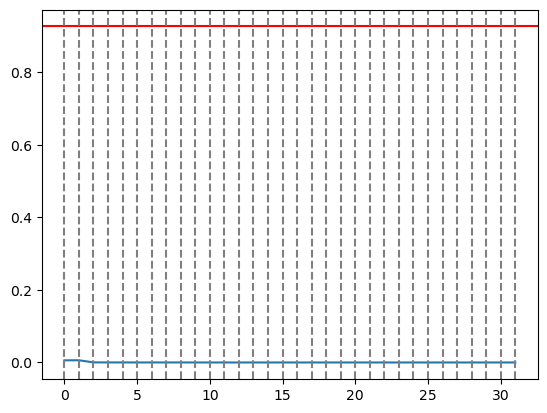

In [42]:
from util.hooks import *
import random

# first three layers mixing orders
num_positions = len(tokens[0])
prob_diff_result = torch.zeros((hook_model.cfg.n_layers, num_positions))
tgt_str_token = test_pair['output']
tgt_token = tokenizer.encode(tgt_str_token)[1]

# parameters
position = [num_positions-1]

tgt_token_scores = []
tmp_tgt_token_scores = np.zeros((hook_model.cfg.n_layers, hook_model.cfg.n_layers))

shuffled_tokens = random.sample(tokens[0].tolist(), len(tokens[0]))
shuffled_tokens = torch.tensor(shuffled_tokens).unsqueeze(0)

print(tokens)
print(shuffled_tokens)
for layer in tqdm.tqdm(range(hook_model.cfg.n_layers)):

    logits, cache = hook_model.run_with_cache(shuffled_tokens, remove_batch_dim=True)
    global_hook_fn = partial(residual_stream_replace_hook, position=position, layer=layer, cache=cache)
    
    # using mix-order cache to patch the clean run
    global_hook_logits = hook_model.run_with_hooks(
        tokens,
        fwd_hooks=\
            [(utils.get_act_name("resid_pre", layer), global_hook_fn)],
        reset_hooks_end=False,
    )
    global_hook_logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)

    # if is the first three layers round, record the score of the target token in each layer
    for i in range(hook_model.cfg.n_layers):
        last_token_h = cache[f"blocks.{i}.hook_resid_post"][-1].cpu()
        
        last_token_proj = project_to_logits(last_token_h)

        tmp_tgt_token_score = torch.softmax(last_token_proj, dim=-1)[tgt_token].cpu()
        tmp_tgt_token_scores[layer, i] = tmp_tgt_token_score

    # get the target token score
    tgt_token_score = torch.softmax(global_hook_logits[0, -1, :], dim=-1)[tgt_token].cpu()
    tgt_token_scores.append(tgt_token_score)


logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)
orig_tgt_token_score = torch.softmax(logits[0, -1, :], dim=-1)[tgt_token].cpu()

# draw the curve of target token score
plt.plot(range(hook_model.cfg.n_layers), tgt_token_scores)
# set the original target token score
plt.axhline(y=orig_tgt_token_score, color='r', linestyle='-')
# set vertical line
for i in range(hook_model.cfg.n_layers):
    plt.axvline(x=i, color='gray', linestyle='--')
plt.show()

In [47]:
ENCODE_LAYER = 3
encode_layers_resid_post = [f'model.layers.{layer}.input_layernorm' for layer in range(ENCODE_LAYER+1)]

with TraceDict(model, layers=encode_layers_resid_post, retain_input=True, retain_output=False) as td:                
    model(**inputs) # batch_size x n_tokens x vocab_size, only want last token prediction

In [49]:
td['model.layers.0.input_layernorm'].input.shape

torch.Size([1, 78, 4096])